Unique classes found in training data: [0 1 2 3 4 5]
Expected: [0, 1, 2, 3, 4, 5]
Loading training data...
Loading testing data...
Train shape: (597, 12288)
Test shape: (144, 12288)

Training SVM...
Training Time: 2.32 seconds

Accuracy: 0.8403

Classification Report:

                precision    recall  f1-score   support

    blue_boost       0.86      1.00      0.92        24
tuna_sandwhich       1.00      0.96      0.98        24
  purple_boost       0.59      0.54      0.57        24
       quavers       0.96      1.00      0.98        24
     red_boost       0.76      0.79      0.78        24
         pepsi       0.86      0.75      0.80        24

      accuracy                           0.84       144
     macro avg       0.84      0.84      0.84       144
  weighted avg       0.84      0.84      0.84       144



<Figure size 1000x800 with 0 Axes>

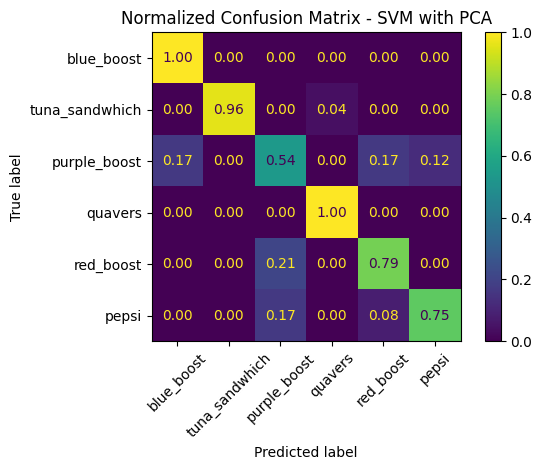


Model saved as svm_fruit_model.pkl


In [7]:
import os
import cv2
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

train_path = "/Users/theabood/Desktop/DataScience/semester3/Datasets/products/train"
test_path  = "/Users/theabood/Desktop/DataScience/semester3/Datasets/products/test"

label_map = {
    'blue_boost': 0,
    'tuna_sandwhich': 1,
    'purple_boost': 2,
    'quavers': 3,
    'red_boost': 4,
    'pepsi': 5,
}

X_train, y_train = load_data(train_path)

print("Unique classes found in training data:", np.unique(y_train))
print("Expected:", list(label_map.values()))

labels = list(label_map.keys())
IMG_SIZE = 64

def load_data(folder_path):
    X, y = [], []

    for product in sorted(os.listdir(folder_path)):
        product_path = os.path.join(folder_path, product)

        if product not in label_map:
            continue

        for img_name in os.listdir(product_path):
            if img_name.startswith("."):
                continue

            img_path = os.path.join(product_path, img_name)

            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img.flatten()

                X.append(img)
                y.append(label_map[product])

            except Exception:
                continue

    return np.array(X), np.array(y)

print("Loading training data...")
X_train, y_train = load_data(train_path)

print("Loading testing data...")
X_test, y_test = load_data(test_path)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=150)),  # dimensionality reduction
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True))
])

print("\nTraining SVM...")
start_time = time.time()

svm_model.fit(X_train, y_train)

end_time = time.time()
print("Training Time: {:.2f} seconds".format(end_time - start_time))

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=labels))

cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format=".2f")

plt.xticks(rotation=45)
plt.title("Normalized Confusion Matrix - SVM with PCA")
plt.tight_layout()
plt.show()

joblib.dump(svm_model, "svm_fruit_model.pkl")
print("\nModel saved as svm_fruit_model.pkl")